# Token Clustering & Centroid Distance Analysis

1. **Token clustering:** Do prompts cluster by token count? If so, is that clustering correlated with condition?
2. **Centroid distance vs expected random distance:** How does the distance between emotional/neutral cluster centroids compare to the expected distance between a random emotional and random neutral sample?

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR  = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR  = BASE_DIR / 'analysis'

# ── Load token counts ──────────────────────────────────────────────────────
tokens = pd.read_csv(DATA_DIR / 'token_counts.csv')
print(f'Token counts loaded: {len(tokens)} prompts')
print(tokens.head())

Token counts loaded: 40 prompts
   condition  prompt_index  n_tokens                        title
0  emotional             0       477                      medical
1  emotional             1       469                          NaN
2  emotional             2       477  Natural disaster evacuation
3  emotional             3       445   Mountain Climbing accident
4  emotional             4       471                   House Fire


## §1 — Token count by condition

In [4]:
for cond in ['emotional', 'neutral']:
    v = tokens[tokens.condition == cond]['n_tokens']
    print(f'{cond:10s}  n={len(v):3d}  mean={v.mean():.1f}  std={v.std():.1f}  min={v.min()}  max={v.max()}')

e = tokens[tokens.condition == 'emotional']['n_tokens']
n = tokens[tokens.condition == 'neutral']['n_tokens']
u, p = mannwhitneyu(e, n, alternative='two-sided')
print(f'\nMann-Whitney U={u:.1f}  p={p:.4f}')
print(f'Token counts differ between conditions: {p < 0.05}')

emotional   n= 20  mean=457.4  std=22.3  min=409  max=485
neutral     n= 20  mean=452.6  std=25.8  min=379  max=499

Mann-Whitney U=217.5  p=0.6454
Token counts differ between conditions: False


In [5]:
# K-means on token count alone — does it recover condition?
X_tok = tokens[['n_tokens']].values
y_tok = (tokens['condition'] == 'emotional').astype(int).values

scaler = StandardScaler()
X_tok_s = scaler.fit_transform(X_tok)
km = KMeans(n_clusters=2, n_init=50, random_state=42)
pred = km.fit_predict(X_tok_s)

cm = confusion_matrix(y_tok, pred)
acc = max((cm[0,0]+cm[1,1])/cm.sum(), (cm[0,1]+cm[1,0])/cm.sum())
ari = adjusted_rand_score(y_tok, pred)

print(f'Clustering on token count alone:')
print(f'  Accuracy: {acc:.4f}  (chance = 0.50)')
print(f'  ARI:      {ari:.4f}')
print(f'\nIf accuracy ≈ 0.50, token count does not separate conditions.')

Clustering on token count alone:
  Accuracy: 0.5250  (chance = 0.50)
  ARI:      -0.0221

If accuracy ≈ 0.50, token count does not separate conditions.


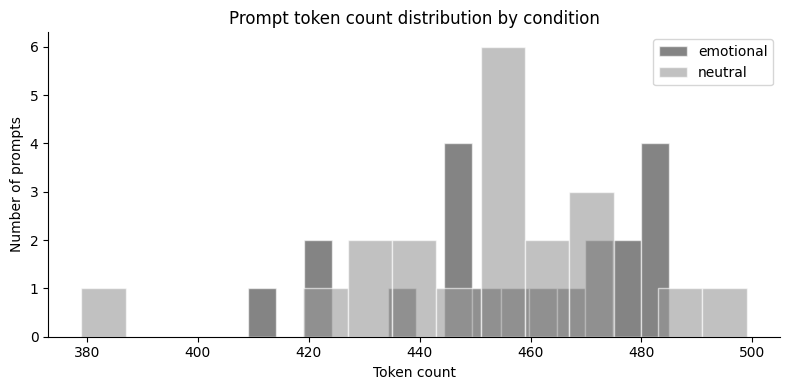

In [6]:
# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
for cond, color in [('emotional', '#333333'), ('neutral', '#999999')]:
    vals = tokens[tokens.condition == cond]['n_tokens']
    ax.hist(vals, bins=15, alpha=0.6, color=color, label=cond, edgecolor='white')
ax.set_xlabel('Token count')
ax.set_ylabel('Number of prompts')
ax.set_title('Prompt token count distribution by condition')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## §2 — Centroid distance vs expected random distance

For the best feature from the main analysis, compare:
- The distance between the emotional and neutral centroids (from k-means)
- The expected distance between a randomly drawn emotional sample and a randomly drawn neutral sample

If the centroid distance is much smaller than the expected random distance, the clusters overlap heavily. If they are comparable, the clustering captures most of the separation.

In [8]:
# ── Load feature data (matching 70b_blocks_analysis.ipynb) ────────────────
DATA_DIR  = BASE_DIR / 'data'

FEATURE_DIR = DATA_DIR / 'longer70b'
RUNS = ['219a', '219b', '219c', '220a', '233a', '233c', '187a', '200a']
BEST_FEATURE = 'core_power.throttle__slope'

dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'blocks{run}', run]:
        p = FEATURE_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

df_all = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'Total trials: {len(df_all)}')
print(f'Feature: {BEST_FEATURE}')

Loaded 8 runs: ['219a', '219b', '219c', '220a', '233a', '233c', '187a', '200a']
Total trials: 320
Feature: core_power.throttle__slope


/var/folders/h6/72885xfn72j09dqwjl2d30yw0000gn/T/ipykernel_92558/2930413343.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d['run'] = run


In [9]:
feat_vals = df_all[BEST_FEATURE].dropna().values
labels = df_all.loc[df_all[BEST_FEATURE].notna(), 'condition'].values

e_vals = feat_vals[labels == 'emotional']
n_vals = feat_vals[labels == 'neutral']

# ── Centroid distance ──────────────────────────────────────────────────────
centroid_e = np.mean(e_vals)
centroid_n = np.mean(n_vals)
centroid_dist = abs(centroid_e - centroid_n)

print(f'Emotional centroid : {centroid_e:.4f}')
print(f'Neutral centroid   : {centroid_n:.4f}')
print(f'Centroid distance  : {centroid_dist:.4f}')

# ── Expected random cross-condition distance ──────────────────────────────
N_PAIRS = 10000
rng = np.random.default_rng(42)
e_samples = rng.choice(e_vals, size=N_PAIRS)
n_samples = rng.choice(n_vals, size=N_PAIRS)
random_dists = np.abs(e_samples - n_samples)

mean_random_dist = np.mean(random_dists)
median_random_dist = np.median(random_dists)
std_random_dist = np.std(random_dists)

print(f'\nExpected random |emotional - neutral| distance:')
print(f'  Mean   : {mean_random_dist:.4f}')
print(f'  Median : {median_random_dist:.4f}')
print(f'  SD     : {std_random_dist:.4f}')

# ── Expected random within-condition distance (baseline) ──────────────────
e_pairs = np.abs(rng.choice(e_vals, N_PAIRS) - rng.choice(e_vals, N_PAIRS))
n_pairs = np.abs(rng.choice(n_vals, N_PAIRS) - rng.choice(n_vals, N_PAIRS))
within_dist = np.mean(np.concatenate([e_pairs, n_pairs]))

print(f'\nExpected random within-condition distance: {within_dist:.4f}')

# ── Ratio ─────────────────────────────────────────────────────────────────
print(f'\nCentroid distance / mean random cross distance: {centroid_dist / mean_random_dist:.4f}')
print(f'Cross-condition / within-condition distance:      {mean_random_dist / within_dist:.4f}')
print(f'\nIf cross/within ≈ 1.0, conditions overlap completely.')
print(f'If cross/within > 1.0, conditions are separated beyond within-group spread.')

Emotional centroid : 2379.1149
Neutral centroid   : 2883.0147
Centroid distance  : 503.8998

Expected random |emotional - neutral| distance:
  Mean   : 1129.6208
  Median : 969.5895
  SD     : 822.6773

Expected random within-condition distance: 1048.0863

Centroid distance / mean random cross distance: 0.4461
Cross-condition / within-condition distance:      1.0778

If cross/within ≈ 1.0, conditions overlap completely.
If cross/within > 1.0, conditions are separated beyond within-group spread.


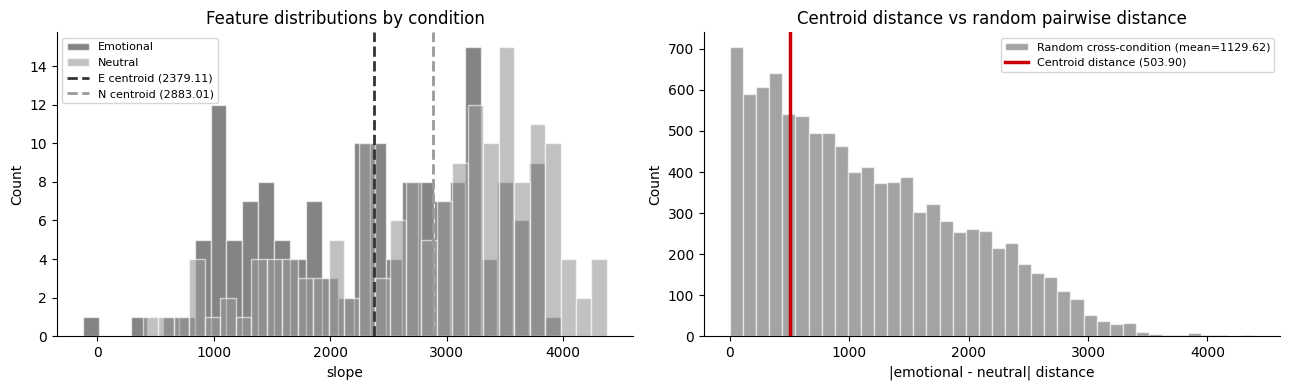

In [10]:
# Visualise the distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: feature distributions
ax = axes[0]
ax.hist(e_vals, bins=30, alpha=0.6, color='#333333', label='Emotional', edgecolor='white')
ax.hist(n_vals, bins=30, alpha=0.6, color='#999999', label='Neutral', edgecolor='white')
ax.axvline(centroid_e, color='#333333', ls='--', lw=2, label=f'E centroid ({centroid_e:.2f})')
ax.axvline(centroid_n, color='#999999', ls='--', lw=2, label=f'N centroid ({centroid_n:.2f})')
ax.set_xlabel(BEST_FEATURE.split('__')[-1])
ax.set_ylabel('Count')
ax.set_title('Feature distributions by condition')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Right: distance distributions
ax = axes[1]
ax.hist(random_dists, bins=40, alpha=0.6, color='#666666', edgecolor='white',
        label=f'Random cross-condition (mean={mean_random_dist:.2f})')
ax.axvline(centroid_dist, color='#cc0000', ls='-', lw=2.5,
           label=f'Centroid distance ({centroid_dist:.2f})')
ax.set_xlabel('|emotional - neutral| distance')
ax.set_ylabel('Count')
ax.set_title('Centroid distance vs random pairwise distance')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()